# P5: Search Consolidation — Humanitarian Routing

**FIT1061 Introduction to Artificial Intelligence — Week 5**

You've now implemented four search algorithms: BFS and DFS (P2), greedy best-first (P3), and hill climbing (P4). This week, you apply what you've learned to a new problem — **humanitarian routing** — and reflect on what values get encoded when algorithms decide who gets help first.

> **This is a milestone task.** Submit your completed notebook and reflection to OnTrack, then be ready to discuss your comparison with your tutor.

---

## Setup

Run the cell below to import everything you need. The search algorithms (BFS, DFS, and greedy best-first) are **provided**; you don't need to re-implement them. This task is about *applying* and *analysing*, not coding from scratch.

In [1]:
from p5_helpers import (HumanitarianGrid, create_disaster_zone,
                        bfs_search, dfs_search, greedy_best_first_search,
                        manhattan_distance, euclidean_distance,
                        reconstruct_path,
                        TARGETS_4, visualise_targets, plot_pareto)
print("Setup OK.")

Setup OK.


---

## Part 1: The scenario

After an earthquake, a relief vehicle must navigate from a **supply depot** (green, marked **D**) to a **target area** (red, marked **T**) through a damaged city district. Dark grey cells represent collapsed blocks, rubble-covered roads, and an unsafe eastern access corridor. The vehicle can only move up, down, left, or right, one block at a time.

Run the cell below to see the disaster zone.

Grid size: 16×16
Blocked roads: 78
Supply depot: row 0, col 0
Target area:  row 15, col 15


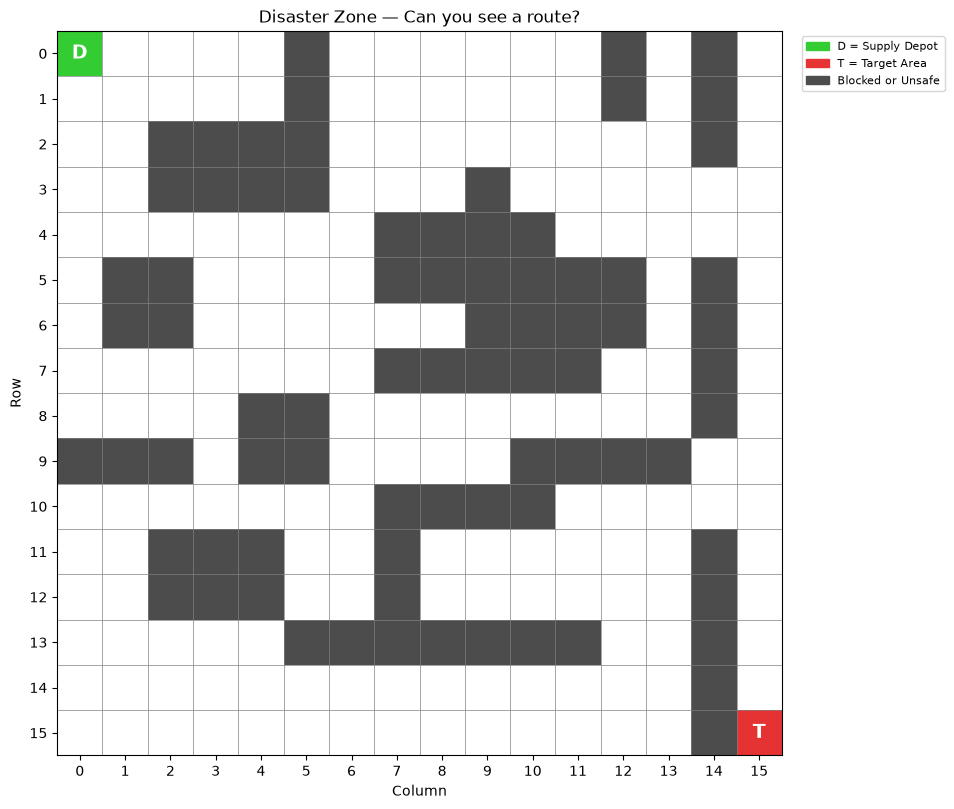

In [2]:
zone = create_disaster_zone()

print(f"Grid size: {zone.rows}×{zone.cols}")
print(f"Blocked roads: {len(zone.obstacles)}")
print(f"Supply depot: row {zone.depot[0]}, col {zone.depot[1]}")
print(f"Target area:  row {zone.target[0]}, col {zone.target[1]}")

zone.visualise(title="Disaster Zone — Can you see a route?")

Look at the grid. Before running any algorithm, try to trace a route by eye from the depot to the target. Is there a direct path, or does the rubble force detours?

---

## Part 2: BFS, the baseline

First, run BFS to find the **shortest route**. BFS is guaranteed to find it (as you learned in P2). This gives us a baseline to compare against.

BFS route length: 34 steps
Nodes expanded: 173
Cells explored: 175


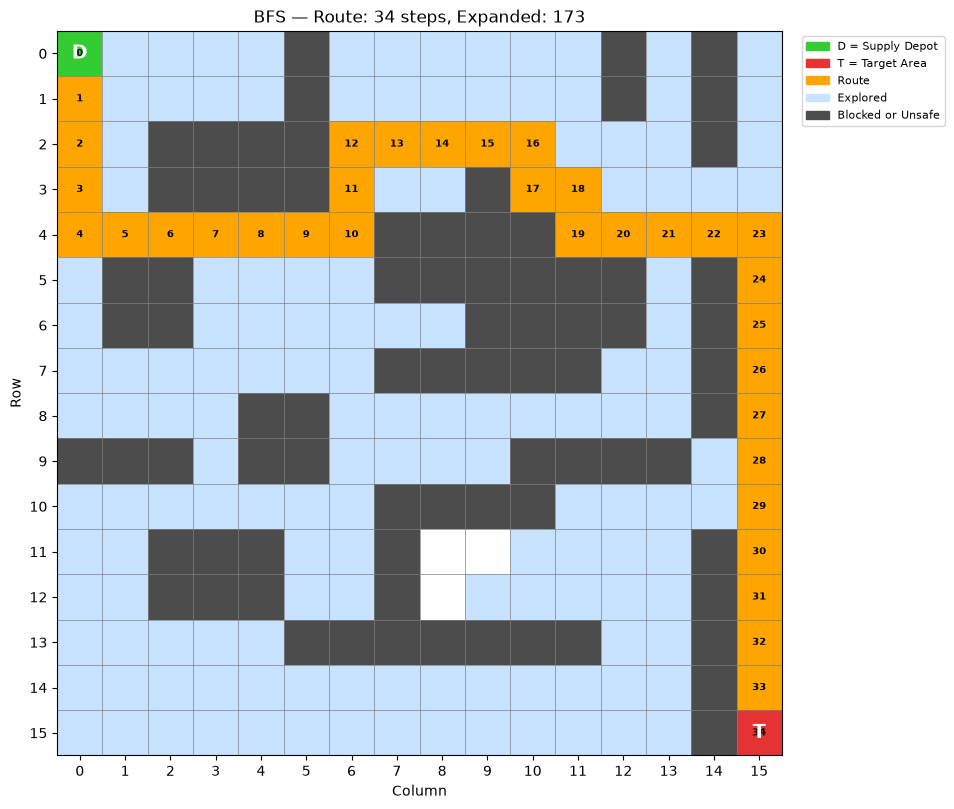

In [3]:
bfs_path, bfs_explored, bfs_expanded = bfs_search(
    zone, zone.depot, zone.target
)

print(f"BFS route length: {len(bfs_path) - 1} steps")
print(f"Nodes expanded: {bfs_expanded}")
print(f"Cells explored: {len(bfs_explored)}")

zone.visualise(path=bfs_path, explored=bfs_explored,
               title=f"BFS — Route: {len(bfs_path) - 1} steps, Expanded: {bfs_expanded}")

Notice how BFS explores in all directions (light blue cells spread everywhere). It's thorough but wasteful: it checks cells far from the goal.

---

## Part 2b: DFS, the depth-first baseline

Now run DFS on the same grid. DFS uses a **stack**, so it commits to one route before checking alternatives. As you learned in P2, DFS finds *a* route but does not guarantee the shortest route.

DFS route length: 50 steps
Nodes expanded: 127
Cells explored: 147


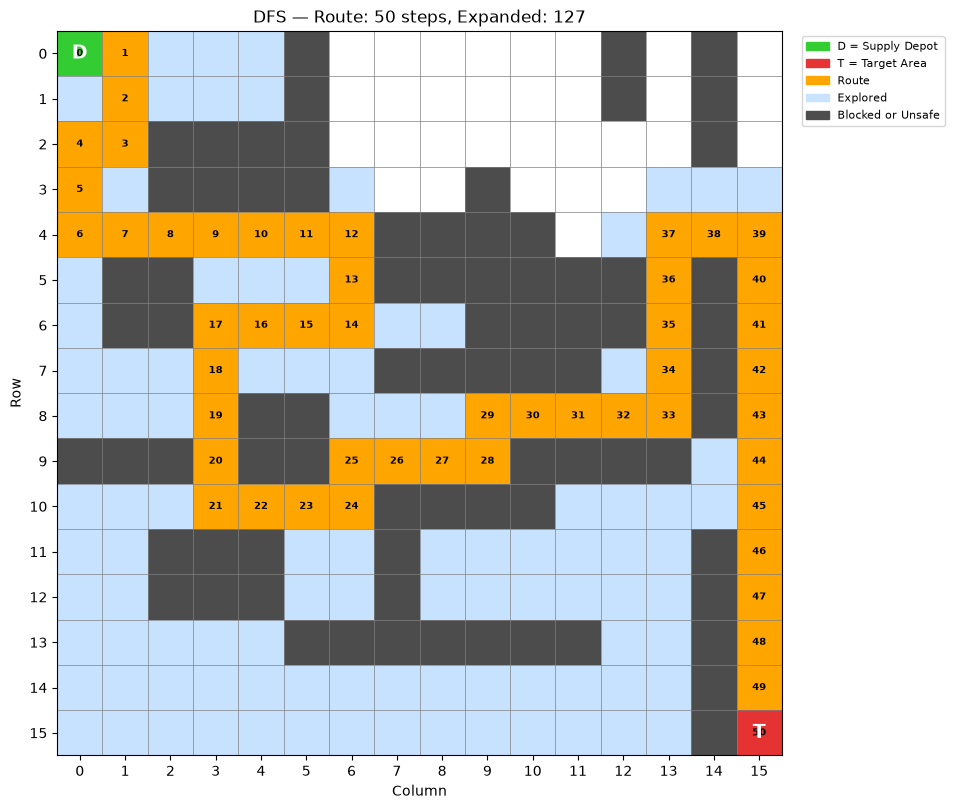

In [4]:
dfs_path, dfs_explored, dfs_expanded = dfs_search(
    zone, zone.depot, zone.target
)

print(f"DFS route length: {len(dfs_path) - 1} steps")
print(f"Nodes expanded: {dfs_expanded}")
print(f"Cells explored: {len(dfs_explored)}")

zone.visualise(path=dfs_path, explored=dfs_explored,
               title=f"DFS — Route: {len(dfs_path) - 1} steps, Expanded: {dfs_expanded}")

Compare the BFS and DFS visualisations. BFS spreads out layer by layer, while DFS dives along one route before backtracking. Where does that difference become visible on this grid?

---

## Part 3: Greedy best-first search, guided by a heuristic (P5.1)

Now run greedy best-first search on the same problem using **Manhattan distance** as the heuristic. This is the same algorithm you implemented in P3, applied to a new grid.

Greedy best-first route length: 42 steps
Nodes expanded: 48
Cells explored: 66


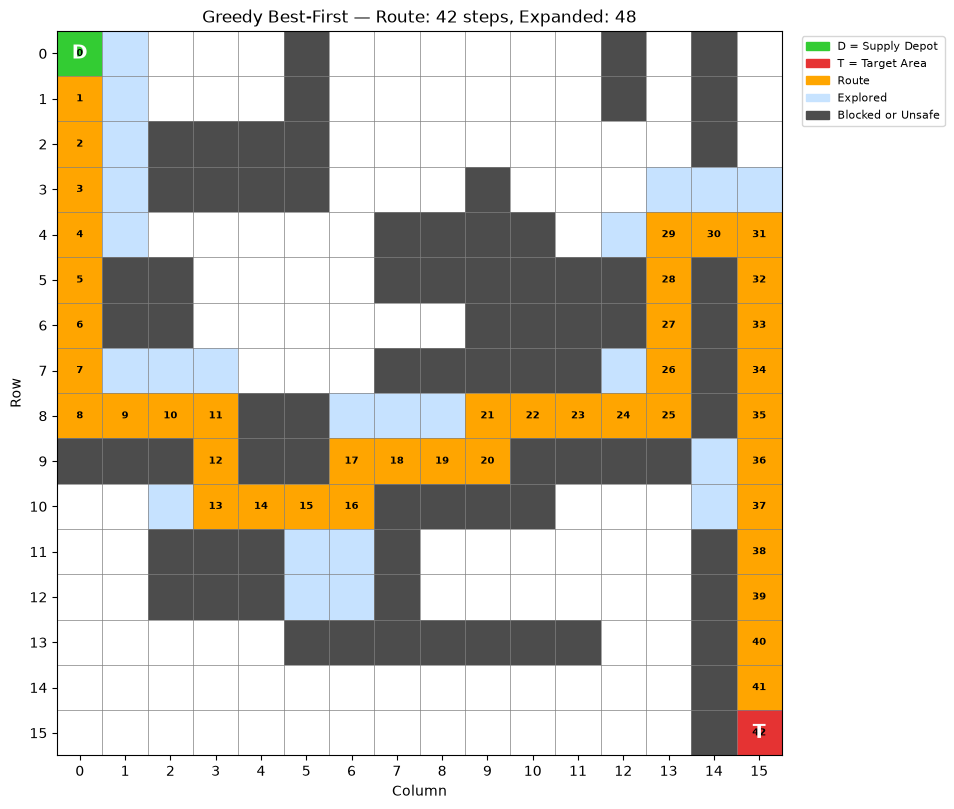

In [5]:
gbfs_path, gbfs_explored, gbfs_expanded = greedy_best_first_search(
    zone, zone.depot, zone.target, manhattan_distance
)

print(f"Greedy best-first route length: {len(gbfs_path) - 1} steps")
print(f"Nodes expanded: {gbfs_expanded}")
print(f"Cells explored: {len(gbfs_explored)}")

zone.visualise(path=gbfs_path, explored=gbfs_explored,
               title=f"Greedy Best-First — Route: {len(gbfs_path) - 1} steps, Expanded: {gbfs_expanded}")

Compare the three visualisations. How do the exploration patterns differ? Where does each algorithm spend its effort?

---

## Part 4: Side-by-side comparison

Run the cell below to print a summary table.

In [6]:
print("Comparison: BFS vs DFS vs Greedy Best-First")
print("=" * 68)
print(f"{'':30s} {'BFS':>10s} {'DFS':>10s} {'Greedy':>10s}")
print("-" * 68)
print(f"{'Route length (steps)':30s} {len(bfs_path) - 1:>10d} {len(dfs_path) - 1:>10d} {len(gbfs_path) - 1:>10d}")
print(f"{'Nodes expanded':30s} {bfs_expanded:>10d} {dfs_expanded:>10d} {gbfs_expanded:>10d}")
print(f"{'Cells explored':30s} {len(bfs_explored):>10d} {len(dfs_explored):>10d} {len(gbfs_explored):>10d}")
print(f"{'Found shortest route?':30s} {'Yes':>10s} {'?':>10s} {'?':>10s}")

Comparison: BFS vs DFS vs Greedy Best-First
                                      BFS        DFS     Greedy
--------------------------------------------------------------------
Route length (steps)                   34         50         42
Nodes expanded                        173        127         48
Cells explored                        175        147         66
Found shortest route?                 Yes          ?          ?


### Record your results

Fill in the comparison table (double-click this cell to edit).

| | BFS | DFS | Greedy Best-First |
|---|---|---|---|
| Route length (steps) | _34__ | _50__ | _42__ |
| Nodes expanded | _173__ | _127__ | _48__ |
| Found shortest route? | Yes | _no__ | _no__ |

---

## Part 5: Guided analysis questions

Answer all four questions below (double-click each cell to edit).

### 5a. Nodes expanded

How many nodes did DFS and greedy best-first search expand compared to BFS? What does this tell you about the effect of exploration order and the efficiency of using a heuristic?

DFS expands 127 nodes, while Greedy bfs only expands 48, both lesser than BFS with 173. Using a herustic can find a path but with less expanded node, while using stack(dfs) expanded lesser node than BFS but the routle length become longer too much. 

### 5b. Route length

Did DFS or greedy best-first search find the shortest route? If not, how much longer were their routes? Explain why each algorithm can miss the shortest route.

DFS and Greedy BFS have very small chance to find shortest route, but mostly is not. For DFS it is largerly depands on how you stack the node, and for greedy BFS it depands on the heurstic you use, becasue it only goes to the smallest herustic. 

### 5c. Exploration pattern

Look at the light blue (explored) cells in all three visualisations. Describe the differences. Where did DFS commit to a route? Did the heuristic guide greedy search in a useful direction, or did it create a problem? Where specifically?

Because DFS went up which in heurstic is getting larger, which is not designed for greedy bfs

### 5d. Euclidean vs Manhattan

Imagine you changed the heuristic from Manhattan distance to Euclidean distance. Would you expect more or fewer nodes expanded? Why? (You can test this below if you want.)

_Your answer here._

In [7]:
# Optional: test with Euclidean distance
euc_path, euc_explored, euc_expanded = greedy_best_first_search(
    zone, zone.depot, zone.target, euclidean_distance
)

print(f"Euclidean heuristic: route={len(euc_path) - 1} steps, expanded={euc_expanded}")
print(f"Manhattan heuristic: route={len(gbfs_path) - 1} steps, expanded={gbfs_expanded}")
print(f"DFS:                 route={len(dfs_path) - 1} steps, expanded={dfs_expanded}")
print(f"BFS (baseline):      route={len(bfs_path) - 1} steps, expanded={bfs_expanded}")

Euclidean heuristic: route=38 steps, expanded=49
Manhattan heuristic: route=42 steps, expanded=48
DFS:                 route=50 steps, expanded=127
BFS (baseline):      route=34 steps, expanded=173


---

## Part 6: When the algorithm has to choose (graded: Pareto frontier)

So far there has been one target. In a real disaster there are **many** areas needing help, with **different costs to reach** and **different numbers of people** at each. A single vehicle has to pick.

The disaster zone now has **four** areas waiting. You will:

1. Compute the path cost from the depot to each area (using BFS: shortest path is fair).
2. Identify which areas lie on the **Pareto frontier** (the set of "best" trade-offs that no other option dominates).
3. Plot the frontier.
4. Reflect on whose values are baked into the *axes* of the trade-off, not just into the algorithm.

> **Pareto frontier (definition).** Option *A* **dominates** option *B* if *A* is at least as good as *B* on every dimension and strictly better on at least one. An option is **Pareto-optimal** if no other option dominates it. The set of Pareto-optimal options is the **Pareto frontier**.

Run the cell below to see the four areas on the map.

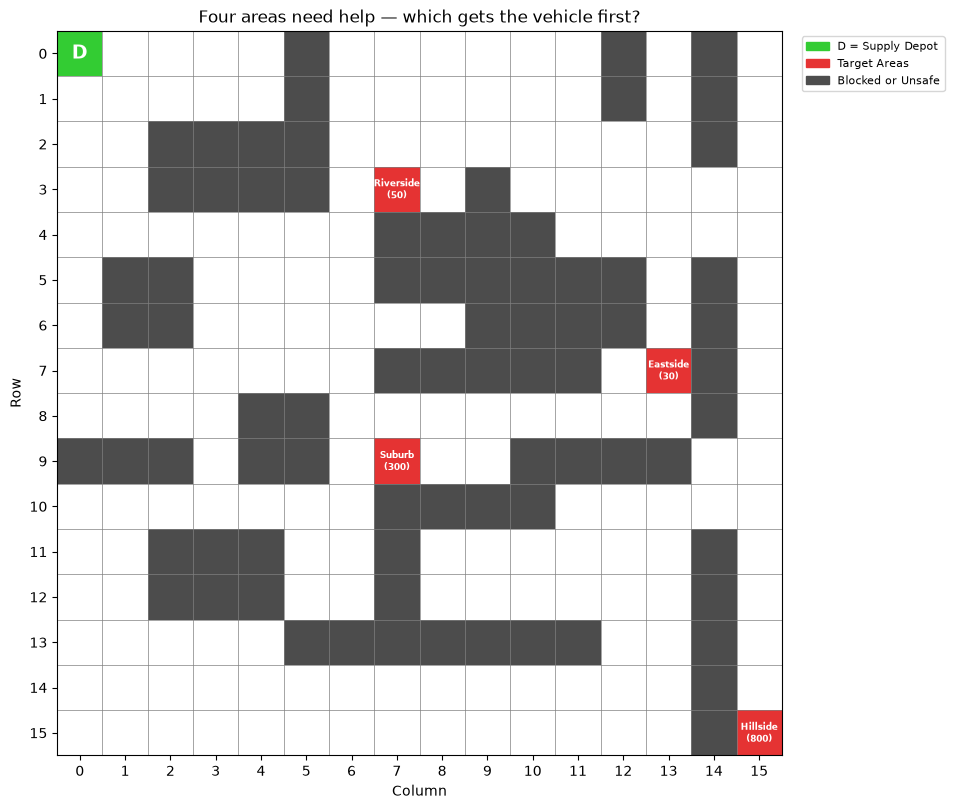

In [8]:
visualise_targets(zone, TARGETS_4,
                  title="Four areas need help — which gets the vehicle first?")

### 6a. Compute the cost-benefit table

Use BFS to find the shortest-path cost from the depot to each target. (BFS is fair: it always returns the shortest route, so the cost is a property of the *map*, not of which algorithm you chose.)

In [9]:
target_names = list(TARGETS_4.keys())
costs = []
populations = []

print(f"{'Target':<20s}  {'Position':>10s}  {'BFS cost':>10s}  {'Population':>11s}")
print("-" * 60)
for name in target_names:
    info = TARGETS_4[name]
    pos = info["position"]
    pop = info["population"]
    path, _, _ = bfs_search(zone, zone.depot, pos)
    cost = len(path) - 1   # number of *steps* (edges), not nodes
    costs.append(cost)
    populations.append(pop)
    print(f"{name:<20s}  {str(pos):>10s}  {cost:>10d}  {pop:>11d}")

Target                  Position    BFS cost   Population
------------------------------------------------------------
Riverside Clinic          (3, 7)          12           50
Suburb Shelter            (9, 7)          16          300
Hillside Shelter        (15, 15)          34          800
Eastside School          (7, 13)          22           30


### 6b. Identify the Pareto frontier

For our two dimensions:
- **Path cost** (*lower is better*, cheaper to reach).
- **Population served** (*higher is better*, more people helped).

Implement `find_pareto_frontier(costs, populations)` that returns the **indices** of the targets on the Pareto frontier.

A target $i$ is **dominated** if there exists some other target $j$ such that
$$\text{cost}_j \le \text{cost}_i \quad \text{and} \quad \text{pop}_j \ge \text{pop}_i \quad \text{and at least one is strict.}$$

Otherwise $i$ is on the frontier.

In [ ]:
def find_pareto_frontier(costs, populations):
    """Return the indices of Pareto-optimal targets.

    Args:
        costs:       list of path costs (lower is better).
        populations: list of population counts (higher is better).
                     Both lists must be the same length.

    Returns:
        A list of integer indices into `costs`/`populations`, in any order,
        identifying the targets that are NOT dominated by any other target.
    """
    n = len(costs)
    frontier = []

    # --- YOUR CODE HERE ---
    # Return the list of indices that are NOT dominated by any other index.
    # (See the definition of "dominates" in the markdown above.)
    # --- END YOUR CODE ---
    for i in range(n):
        dominated= False
        for j in range(n): 
            if i==j:
                continue
            cost= costs[j]<=costs[i] #less cost
            pop= populations[j]>=populations[i] #higher value
            strict= (costs[j]<costs[i]) or (populations[j]>populations[i])#at least one fulfilled
            if cost and pop and strict: 
                dominated=True
                break
        if not dominated:
            frontier.append(i)
    return frontier


# Test on the canonical case from Part 6a.
pareto_indices = find_pareto_frontier(costs, populations)
print(f"Pareto-optimal indices: {pareto_indices}")
print(f"Pareto-optimal targets:")
for i in pareto_indices:
    print(f"  {target_names[i]:<20s}  cost={costs[i]:>3d}  pop={populations[i]:>4d}")

dominated = [i for i in range(len(costs)) if i not in pareto_indices]
print(f"\nDominated targets:")
for i in dominated:
    print(f"  {target_names[i]:<20s}  cost={costs[i]:>3d}  pop={populations[i]:>4d}")

Pareto-optimal indices: [0, 1, 2]
Pareto-optimal targets:
  Riverside Clinic      cost= 12  pop=  50
  Suburb Shelter        cost= 16  pop= 300
  Hillside Shelter      cost= 34  pop= 800

Dominated targets:
  Eastside School       cost= 22  pop=  30


### 6c. Plot the frontier

Pass your result to `plot_pareto`. Pareto-optimal points are highlighted in Monash Blue; dominated points appear in grey. The dashed line shows the trade-off curve: moving along it costs you more steps in exchange for more people served.

c:\introduction to AI\P5-resources\p5_helpers.py:336: UserWarning: You passed an edgecolor/edgecolors ('#969696') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(c, p, s=size, c=colour, marker=marker,


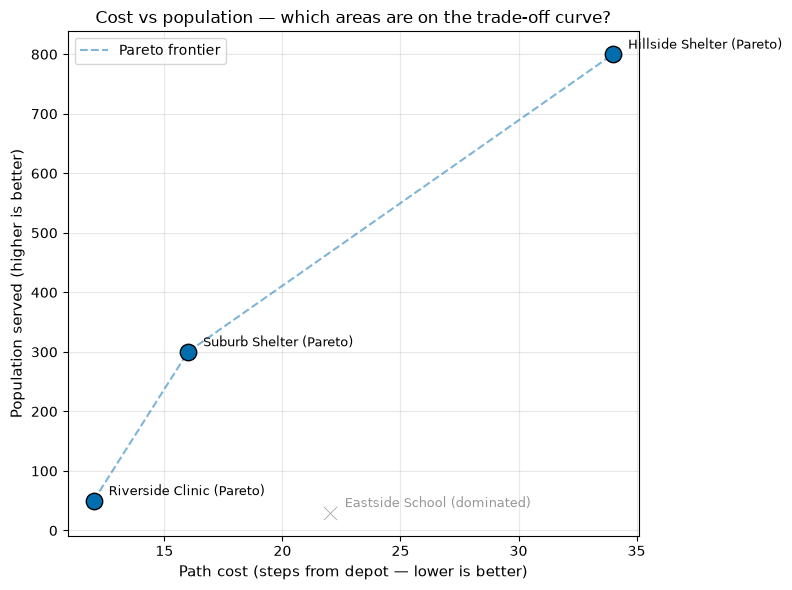

In [13]:
plot_pareto(target_names, costs, populations, pareto_indices,
            title="Cost vs population — which areas are on the trade-off curve?")

### 6d. The values baked into the axes (P5.4: 250-350 words, graded)

The Pareto frontier tells you which options are "trade-offs you cannot beat." But it does not tell you **which trade-off to pick**: that is a *value* judgment about which axis matters more.

> *"When algorithms decide who gets help first, what values are encoded in the heuristic?"*

After the 2010 Haiti earthquake, AI-powered routing helped coordinate relief. But the heuristic determines the priority: closest first? Most people first? Most vulnerable first? Each choice reflects a value judgment. The same is true of the *axes* you plotted your Pareto frontier on: choosing to measure "path cost" and "population served" is itself a decision about what (and who) counts.

Answer all three. Cite *specific* targets and numbers from your table where possible.

1. **Which targets are dominated, and which dominate them?** For each dominated target, name at least one Pareto-optimal target that dominates it, and quote the (cost, population) numbers that prove it.
2. **Who decides which axis matters more?** A relief coordinator who picks the *fastest* response (lowest cost) reaches Riverside first. One who picks the *most-people-helped-per-trip* (highest population) reaches Hillside first. Both choices are on the Pareto frontier; neither is "wrong." Whose voice is missing from this trade-off, and why does that matter?
3. **The axes themselves.** "Path cost" is a proxy for *aid-worker time*. "Population served" is a proxy for *who counts as needing aid*. Suppose you replaced "population served" with **vulnerability index**, a composite score that weights children, elderly, medical needs, displacement. You do not need to implement this. Just describe: would the Pareto frontier likely change? Which target would move? Whose interests are now centred, and whose are pushed off the frontier?

_Your answer here._
1. Eastside School is the dominated one, means it has the worst value to resecue. While other three points are dominate, then is up to human to decide which is better.
2. It is up to preferance, I prefer Hillside shelter as my first destination, because there are more population, which can create larger value for me. However if you check the distance, it is more than Riverside Clinic add Suburb Shelter's distance. If one cares more about distance, than it will choose Riverside Clinic. 
3. I don't think it will change the graph, because it is basiclly comparing if there is a "better" numbers in this 4 selection. So Eastside school will still remain dominated, where as the rest three point to be dominate. It effect more in the next step, because the meaning for human is different, and will effect our dicision. For example, if cure time means heavier degree of injury, then we should consider to save them first, which Hillside Shelter will be the best option, because it has more people need aid and is more heavy injured.    
> **Connection to W09–W12.** Every classifier and every algorithm scoring people sits on some implicit Pareto frontier: usually precision vs recall (W08–W09), or accuracy vs subgroup-fairness (W09). The frontier shape is a mathematical fact about the data. *Where on the frontier you sit* is a political fact about whose errors you are willing to tolerate. P5 is the first time you see this; it will not be the last.